# Eksperimen E4: Domain Shift pada Real Soundscape

Notebook ini dirancang untuk menjawab Tantangan **Domain Shift** dalam bioakustik. Kita akan menguji seberapa besar performa model AI pengenal suara burung (*BirdNET, PANNs CNN14, dkk.*) jatuh ketika deraunya diganti dari **Derau Lingkungan Terkontrol (AudioMoth ITERA di E2)** menjadi **Derau Alam Bebas yang Autentik (Rekaman Soundscape Hutan BirdCLEF)**.

## Objektif
1. Mensimulasikan kondisi akustik ekstrem dengan mengambil acak (*random crop*) 5 detik dari rekaman utuh hutan tropis (`train_soundscapes`).
2. Menyuntikkan derau hutan tersebut ke kicauan bersih burung dengan level keparahan (*Signal-to-Noise Ratio* / SNR) yang persis sama dengan E2: 20dB, 10dB, 0dB, dan -5dB.
3. Membedah hasil *Mean Average Precision* (mAP@10).

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from pathlib import Path
import IPython.display as ipd

# 1. Pastikan jalur repository sistem terbaca
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocess import preprocess_audio, TARGET_SR, TARGET_SAMPLES
from src.embeddings import AudioRepresentationExtractor
from src.mix_noise import compute_signal_power
from src.retrieve import evaluate_retrieval_corpus

print("[+] Seluruh Pustaka dan Modul Inti (src) Berhasil Dimuat!")

[+] Seluruh Pustaka dan Modul Inti (src) Berhasil Dimuat!


## Tahap 1: Ekstraksi Derau dari *Soundscape* Alam
Fungsi di bawah ini didesain secara khusus untuk mengambil acak 1 file `.ogg` dari 10.658 file di folder `data/BirdClef/train_soundscapes`, me-*load*-nya dengan `librosa`, lalu memotong tepat 5 detik audio secara acak.

In [2]:
SOUNDSCAPE_DIR = PROJECT_ROOT / "data/BirdClef/train_soundscapes"

def get_soundscape_noise_segment(samples: int = TARGET_SAMPLES, seed: int = 42) -> np.ndarray:
    """Mengekstrak segmen derau acak dari rekaman soundscape .ogg"""
    rng = np.random.default_rng(seed)
    ogg_files = [f for f in os.listdir(SOUNDSCAPE_DIR) if f.endswith('.ogg')]
    selected = str(SOUNDSCAPE_DIR / rng.choice(ogg_files))
    
    try:
        y, _ = librosa.load(selected, sr=TARGET_SR, mono=True)
        if len(y) >= samples:
            start = rng.integers(0, len(y) - samples + 1)
            return y[start:start + samples].astype(np.float32)
        else:
            repeats = int(np.ceil(samples / len(y)))
            y = np.tile(y, repeats)
            return y[:samples].astype(np.float32)
    except Exception as e:
        print(f"Error memuat {selected}: {e}")
        return np.zeros(samples, dtype=np.float32)

def mix_with_soundscape(clean: np.ndarray, snr_db: float, seed: int = 42) -> np.ndarray:
    """Menyatukan sinyal asli dan derau alam pada tingkat SNR (dB) eksak."""
    noise = get_soundscape_noise_segment(samples=len(clean), seed=seed)
    
    p_signal = compute_signal_power(clean)
    p_noise = compute_signal_power(noise)
    
    if p_signal <= 1e-12 or p_noise <= 1e-12:
        return clean
        
    target_p_noise = p_signal / (10.0 ** (snr_db / 10.0))
    alpha = np.sqrt(target_p_noise / p_noise)
    noisy = clean + alpha * noise
    
    max_amp = np.max(np.abs(noisy))
    if max_amp > 1.0:
        noisy = noisy / max_amp
        
    return noisy.astype(np.float32)

### Visualisasi Injeksi Derau Hutan Tropis (-5 dB)
Mari kita intip bentuk gelombangnya. Di SNR -5dB, suara burung akan sangat tenggelam ke dalam latar belakang suara jangkrik/hujan/sungai yang ada pada file soundscape.

c:\Users\Fabio\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


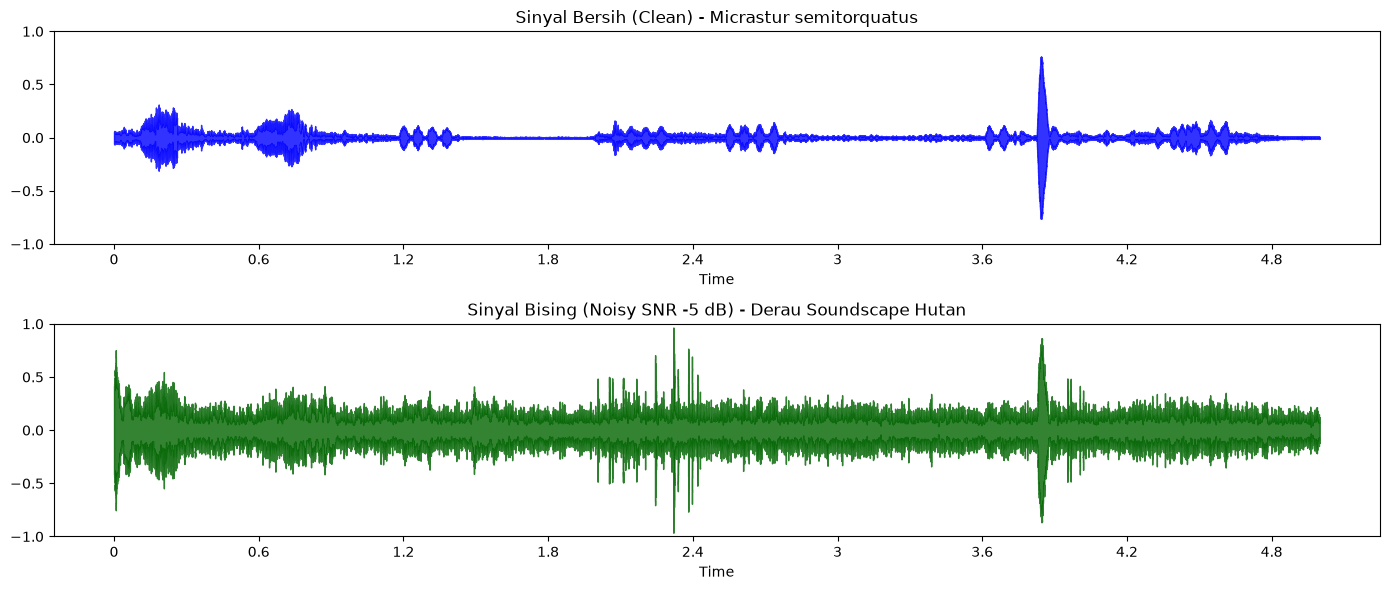

In [3]:
# Mengambil satu kueri bersih sebagai kelinci percobaan
df_split = pd.read_csv(PROJECT_ROOT / "data/manifests/dataset_split.csv")
sample_query = df_split[df_split['split_role'] == 'query_clean'].iloc[0]

clean_wav = preprocess_audio(str(PROJECT_ROOT / sample_query['file_path']))
noisy_wav = mix_with_soundscape(clean_wav, snr_db=-5, seed=123)

plt.figure(figsize=(14, 6))
plt.subplot(2, 1, 1)
librosa.display.waveshow(clean_wav, sr=TARGET_SR, alpha=0.8, color='blue')
plt.title(f"Sinyal Bersih (Clean) - {sample_query['scientific_name']}")
plt.ylim([-1, 1])

plt.subplot(2, 1, 2)
librosa.display.waveshow(noisy_wav, sr=TARGET_SR, alpha=0.8, color='darkgreen')
plt.title("Sinyal Bising (Noisy SNR -5 dB) - Derau Soundscape Hutan")
plt.ylim([-1, 1])

plt.tight_layout()
plt.show()

## Tahap 2: Eksekusi Komputasi Ekstraksi Fitur (E4 Pipeline)
Tahap ini akan mengekstraksi vektor angka dari seluruh dataset menggunakan representasi R2 (BirdNET) sebagai sampel evaluasi utama kita. Komputasi ini dapat memakan waktu 1-3 menit.

In [4]:
extractor = AudioRepresentationExtractor("R2")  # Fokus ke model terbaik (R2)
gallery_df = df_split[df_split['split_role'] == 'gallery']
query_df = df_split[df_split['split_role'] == 'query_clean']

# --- 1. Bangun Matriks Galeri ---
gallery_embs, gallery_labels = [], []
for _, r in gallery_df.iterrows():
    gallery_embs.append(extractor.extract(preprocess_audio(str(PROJECT_ROOT / r['file_path']))))
    gallery_labels.append(r['species_key'])
gallery_embs = np.array(gallery_embs)

# --- 2. Siapkan Kueri Audio ---
query_audios, query_labels = [], []
for _, r in query_df.iterrows():
    query_audios.append(preprocess_audio(str(PROJECT_ROOT / r['file_path'])))
    query_labels.append(r['species_key'])

# --- 3. Uji pada tiap Kondisi SNR (Soundscape) ---
snr_grid = [20, 10, 0, -5]
results_e4 = []

for snr in snr_grid:
    print(f"[*] Mengevaluasi R2 pada Derau Hutan SNR {snr:2d} dB...")
    noisy_embs = []
    for i, y_c in enumerate(query_audios):
        y_n = mix_with_soundscape(y_c, snr_db=snr, seed=900+i)
        noisy_embs.append(extractor.extract(y_n))
    
    noisy_embs = np.array(noisy_embs)
    summary, _ = evaluate_retrieval_corpus(noisy_embs, query_labels, gallery_embs, gallery_labels)
    results_e4.append({"SNR (dB)": snr, "mAP@10 (E4)": summary["mAP@10"]})

df_e4 = pd.DataFrame(results_e4)
display(df_e4)

[*] Mengevaluasi R2 pada Derau Hutan SNR 20 dB...
[*] Mengevaluasi R2 pada Derau Hutan SNR 10 dB...
[*] Mengevaluasi R2 pada Derau Hutan SNR  0 dB...
[*] Mengevaluasi R2 pada Derau Hutan SNR -5 dB...


,SNR (dB),mAP@10 (E4)
0,20,0.913998
1,10,0.890357
2,0,0.819834
3,-5,0.757580
